In [ ]:
import os
os.chdir(r"C:\Projects\gait_ml")
print("当前工作目录已切换到:", os.getcwd())


当前工作目录已切换到: C:\Projects\gait_ml


In [ ]:
import pandas as pd

file_path = r"data/phase_binned_summary/binned_phase_summary_walking_4kmh.csv"

# 不跳过任何行，先完整读取看结构
df_raw = pd.read_csv(file_path)
print("原始读取的前5行（完整结构）：")
print(df_raw.head(10))  # 多看几行看清表头
print("\n原始列名：", df_raw.columns.tolist())

原始读取的前5行（完整结构）：
            Unnamed: 0          knee_angle        knee_angle.1 knee_angle.2  \
0                  NaN                mean                 std        count   
1            phase_bin                 NaN                 NaN          NaN   
2                  0.0  5.4570416666667185   3.710546482379429          552   
3                 0.05  13.156888888889029  3.6192328252908106          540   
4                  0.1  22.355952651515285   4.147593924443654          528   
5  0.15000000000000002  26.138815238095148   3.085560937620058          525   
6                  0.2   17.84296810506551  4.1944702055647145          533   
7                 0.25  7.1559517625230455   3.591506067150848          539   
8  0.30000000000000004   2.232801136363583    2.45133623403526          528   
9  0.35000000000000003  0.7069354838709416   1.878124302853841          527   

          knee_ang_vel      knee_ang_vel.1 knee_ang_vel.2  \
0                 mean                 std          c

读取后的列名（MultiIndex）：
[('knee_angle', 'mean'), ('knee_angle', 'std'), ('knee_angle', 'count'), ('knee_ang_vel', 'mean'), ('knee_ang_vel', 'std'), ('knee_ang_vel', 'count'), ('ax', 'mean'), ('ax', 'std'), ('ax', 'count'), ('ay', 'mean'), ('ay', 'std'), ('ay', 'count'), ('az', 'mean'), ('az', 'std'), ('az', 'count'), ('gx', 'mean'), ('gx', 'std'), ('gx', 'count'), ('gy', 'mean'), ('gy', 'std'), ('gy', 'count'), ('gz', 'mean'), ('gz', 'std'), ('gz', 'count'), ('heel_fsr', 'mean'), ('heel_fsr', 'std'), ('heel_fsr', 'count'), ('toe_fsr', 'mean'), ('toe_fsr', 'std'), ('toe_fsr', 'count'), ('cycle_duration_s', 'mean'), ('cycle_duration_s', 'std')]

前5行数据：
          knee_angle                 knee_ang_vel                         ax  \
                mean       std count         mean        std count      mean   
phase_bin                                                                      
0.00        2.080731  2.430547   483    99.109493  30.811196   483 -0.149362   
0.05        6.424865  1.4

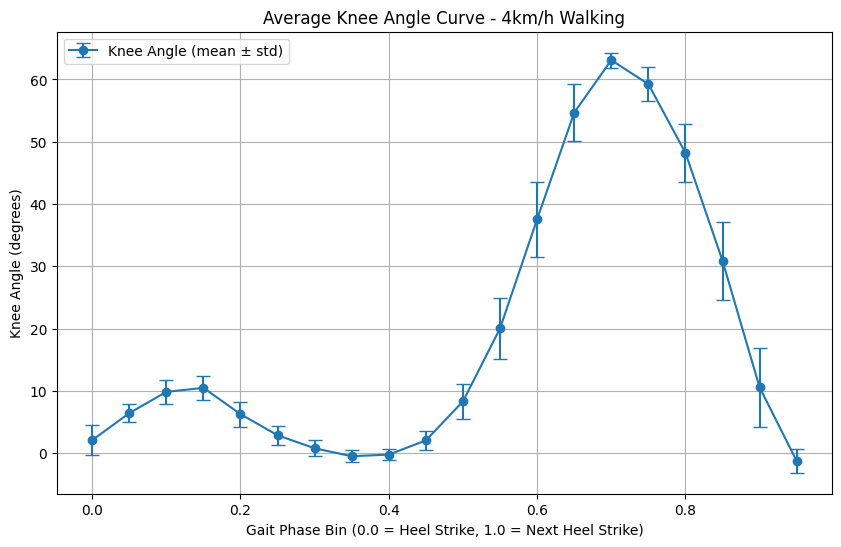

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 强制切换工作目录（防止路径问题）
import os
os.chdir(r"C:\Projects\gait_ml")
print("当前工作目录:", os.getcwd())

file_path = r"data/phase_binned_summary/binned_phase_summary_walking_4kmh.csv"  # 想看的速度

# 正确读取方式（跳过第一行标题，自动处理扁平列名）
df = pd.read_csv(file_path, skiprows=1)
df = df.rename(columns={'Unnamed: 0': 'phase_bin'})

# 自动重命名列（mean / std / count）
rename_dict = {}
for col in df.columns:
    if col.endswith('.1'):
        base = col.replace('.1', '')
        rename_dict[col] = f"{base}_std"
    elif col.endswith('.2'):
        base = col.replace('.2', '')
        rename_dict[col] = f"{base}_count"
    elif col != 'phase_bin':
        rename_dict[col] = f"{col}_mean"

df = df.rename(columns=rename_dict)

print("重命名后列名:", df.columns.tolist())
print("\n前5行数据预览:")
print(df.head())

# 绘图
plt.figure(figsize=(10, 6))
plt.errorbar(
    df['phase_bin'],
    df['knee_angle_mean'],
    yerr=df['knee_angle_std'],
    fmt='o-', capsize=5, label='Knee Angle (mean ± std)'
)
plt.xlabel('Gait Phase Bin (0.0 = Heel Strike, 1.0 = Next Heel Strike)')
plt.ylabel('Knee Angle (degrees)')
plt.title('Average Knee Angle Curve - 4km/h Walking')
plt.grid(True)
plt.legend()

# 保存图片（避免 VS Code 卡住）
plt.savefig('average_knee_4kmh.png', dpi=150, bbox_inches='tight')
plt.close()   # 关闭图像，防止卡住
print("图片已保存为 average_knee_4kmh.png（可在 data 文件夹找到）")